In [1]:
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import nnx
import nnx.functional as Fx
import nnx.graphics as G


/home/wipkat/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


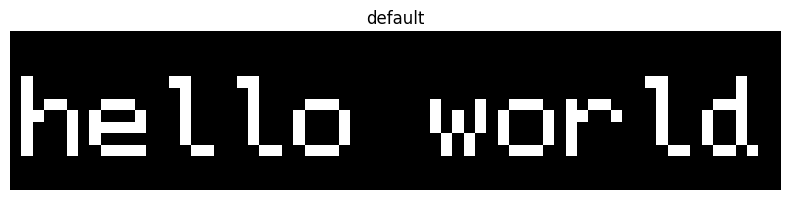

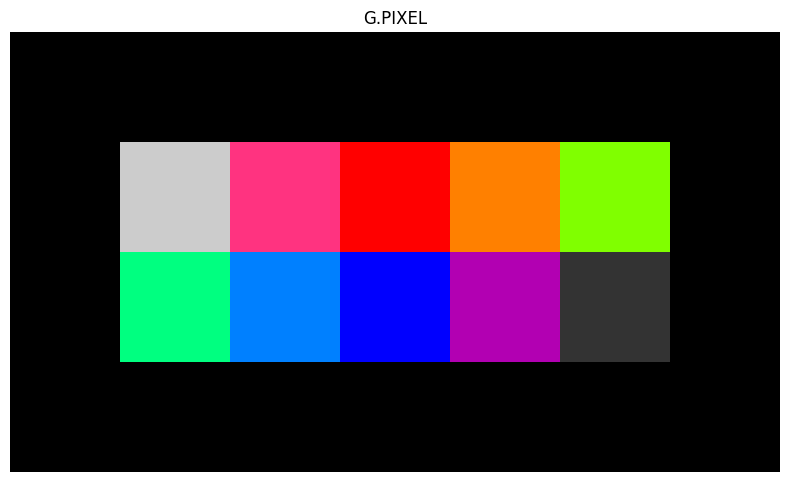

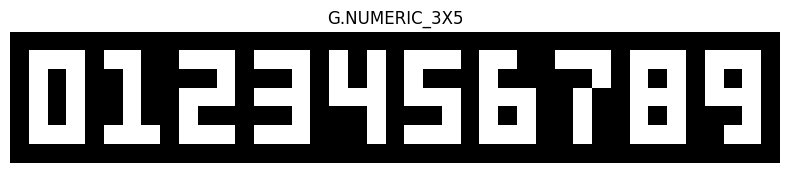

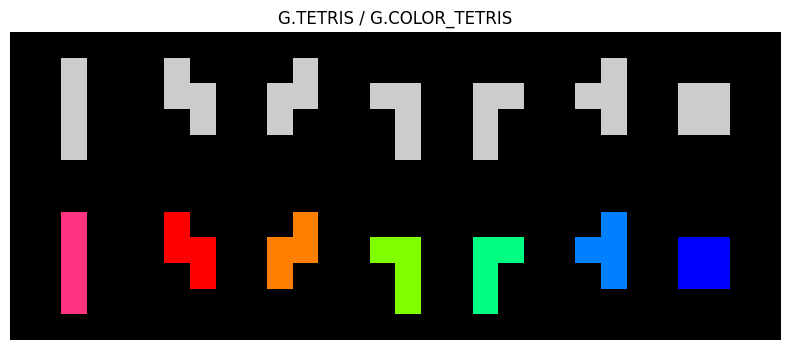

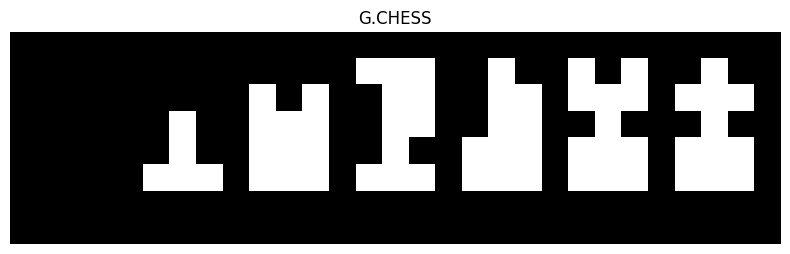

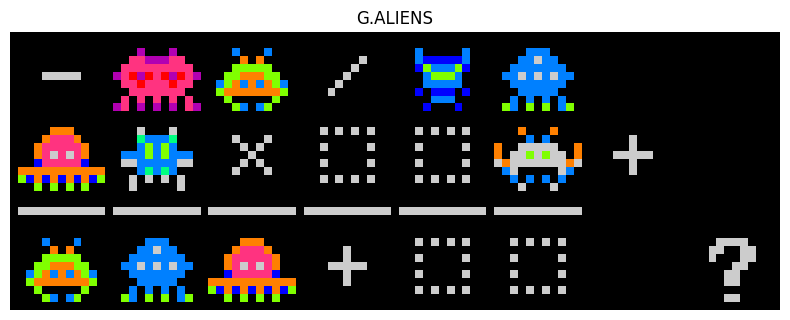

In [2]:
image = G.render_text("hello world")
G.plot(image, width=10, title="default")


image = G.render_text("01234\n56789", font=G.PIXEL, colorspace="rgb")
G.plot(image, width=10, title="G.PIXEL")


image = G.render_text("0123456789", font=G.NUMERIC_5X3, spacing=1)
G.plot(image, width=10, title="G.NUMERIC_3X5")


image_mono = G.render_text("0123456", font=G.TETRIS, colorspace="rgb")
image_color = G.render_text("0123456", font=G.COLOR_TETRIS, colorspace="rgb")
image = torch.cat([image_mono, image_color],-2)
G.plot(image, width=10, title="G.TETRIS / G.COLOR_TETRIS")


image = G.render_text(".prnbqk", font=G.CHESS, spacing=1)
G.plot(image, width=10, title="G.CHESS")

image = G.render_text("-12/34 \n56*##9+\n______\n245+## ?", font=G.ALIENS, spacing=1, colorspace="rgb")
G.plot(image, width=10, title="G.ALIENS")



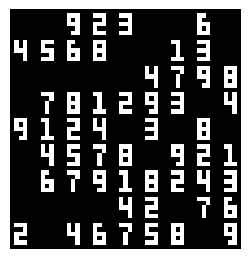

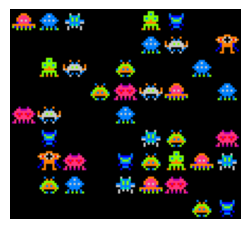

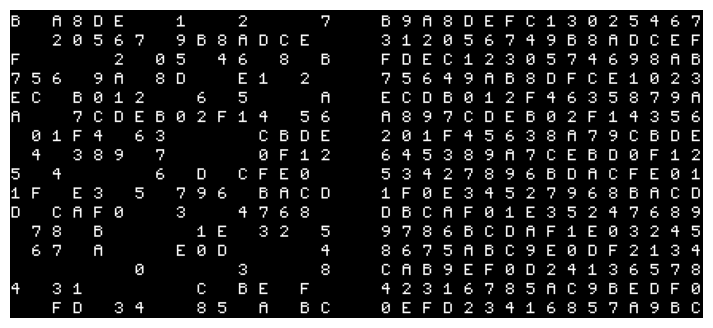

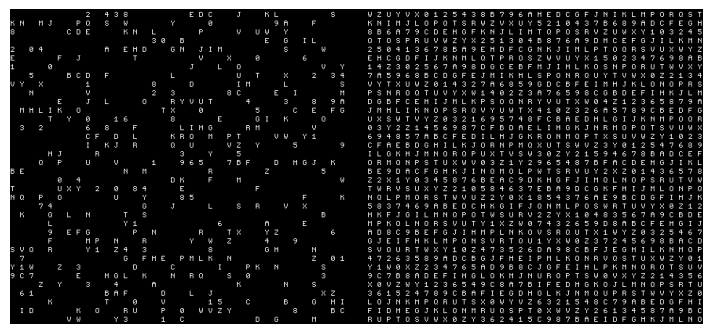

In [15]:
from nnx.graphics.sudoku import render_sudoku

challenge, solution = render_sudoku()
G.plot(challenge, width=3)

challenge, solution = render_sudoku(spacing=(2,1), difficulty=0.6, font=G.ALIENS, colorspace="rgb")
G.plot(challenge, width=3)

challenge, solution = render_sudoku(4, spacing=(0,7),font=G.DEFAULT)
image = torch.cat([challenge, torch.zeros(1,challenge.shape[-2], 30, device=challenge.device), solution],-1)
G.plot(image, width=9)

challenge, solution = render_sudoku(6, spacing=(0,7), difficulty=0.7, font=G.DEFAULT)
image = torch.cat([challenge, torch.zeros(1,challenge.shape[-2], 30, device=challenge.device), solution],-1)
G.plot(image, width=9)



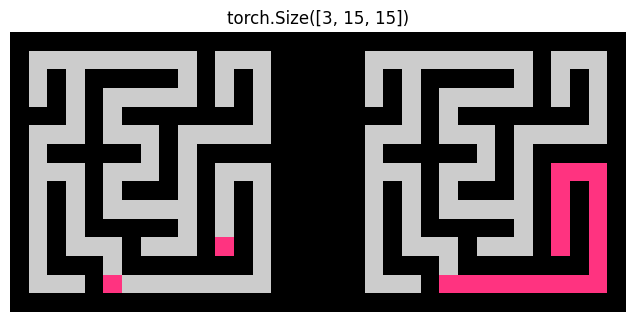

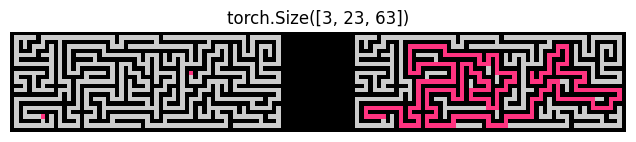

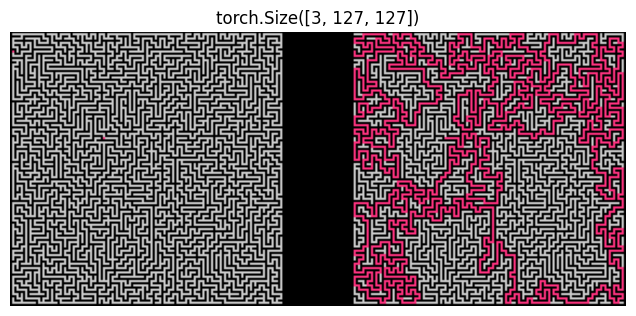

In [5]:
from nnx.graphics.maze import render_maze

challenge, solution = render_maze((8,8), colorspace="rgb")
image = torch.cat([challenge, torch.zeros(*challenge.shape[:-1], challenge.shape[-1]//4, device=challenge.device), solution],-1)
G.plot(image, title=str(challenge.shape), width=8)

challenge, solution = render_maze((12,32),colorspace="rgb")
image = torch.cat([challenge, torch.zeros(*challenge.shape[:-1], challenge.shape[-1]//4, device=challenge.device), solution],-1)
G.plot(image, title=str(challenge.shape), width=8)

challenge, solution = render_maze((64,64),colorspace="rgb")
image = torch.cat([challenge, torch.zeros(*challenge.shape[:-1], challenge.shape[-1]//4, device=challenge.device), solution],-1)
G.plot(image, title=str(challenge.shape), width=8)

